In [11]:
from astropy.io import fits
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LogNorm

path_to_data = Path.home() / "Downloads/data/output_2026-07-17_10-24-48"

/Users/kaladin/dygdug/dygdug/post_processing.py:25: RuntimeWarning: divide by zero encountered in divide
  Icoh_sin = (dI1 ** 2) / (8 * denI1)
/Users/kaladin/dygdug/dygdug/post_processing.py:25: RuntimeWarning: invalid value encountered in divide
  Icoh_sin = (dI1 ** 2) / (8 * denI1)
/Users/kaladin/dygdug/dygdug/post_processing.py:26: RuntimeWarning: divide by zero encountered in divide
  Icoh_cos = (dI2 ** 2) / (8 * denI2)
/Users/kaladin/dygdug/dygdug/post_processing.py:26: RuntimeWarning: invalid value encountered in divide
  Icoh_cos = (dI2 ** 2) / (8 * denI2)


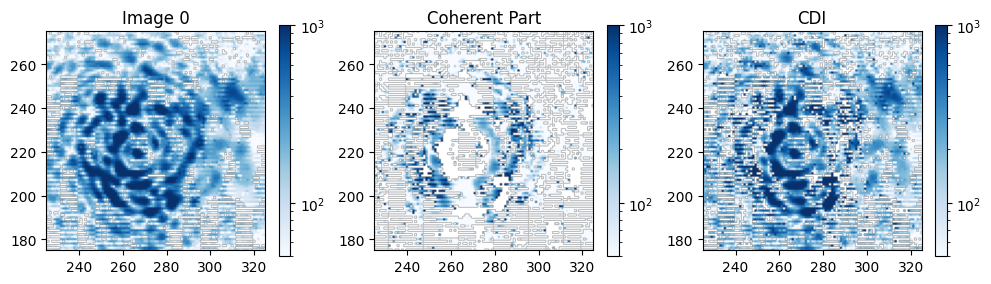

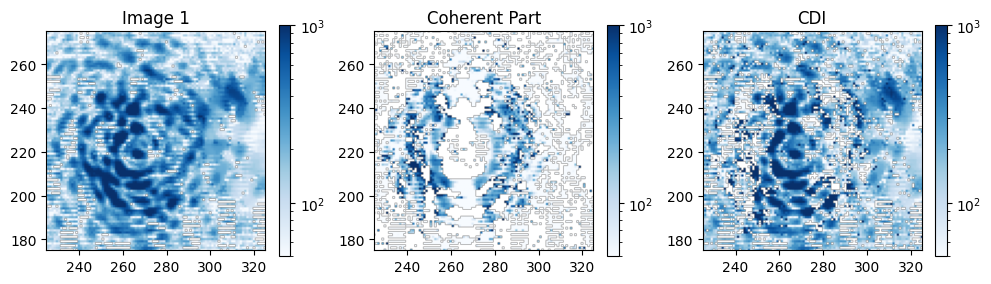

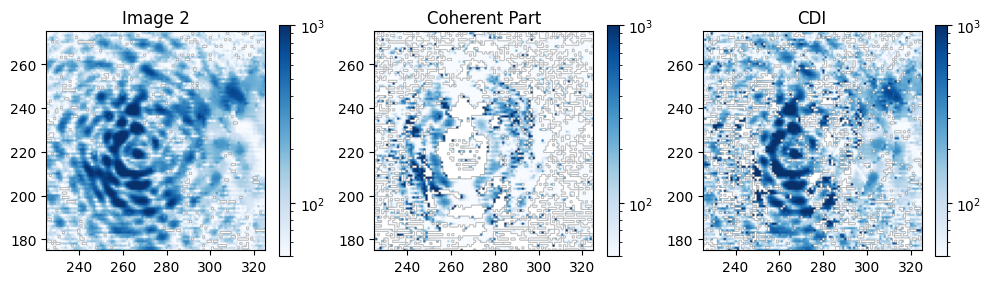

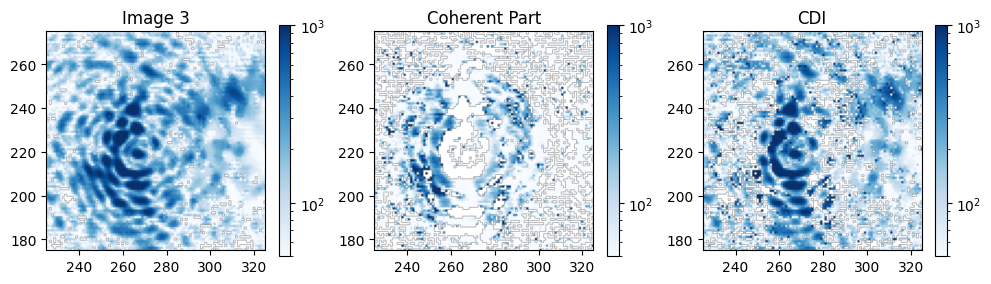

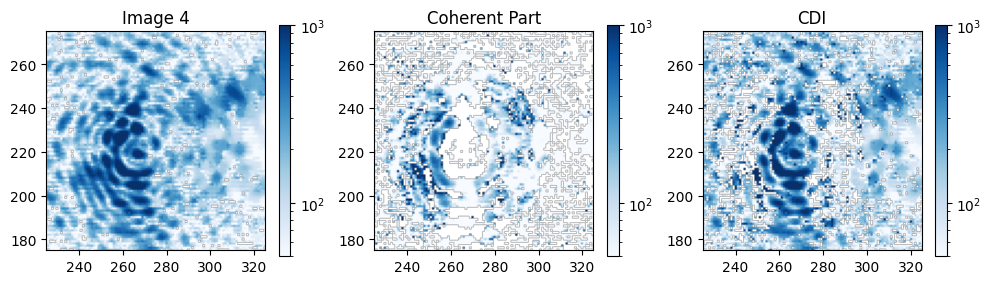

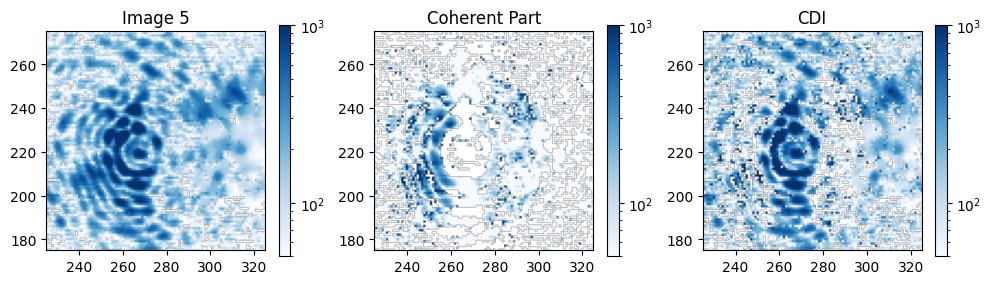

In [25]:
# Data is ordered
# I0, Im1, Ip1, Im2, Ip2
for i in range(6):
    file_path = path_to_data / f"SAN_iter{i}_intermediates_ND1_5ms.fits"
    with fits.open(file_path) as hdul:
        image_data = hdul[0].data
        I0 = image_data[0]
        Im1 = image_data[1]
        Ip1 = image_data[2]
        Im2 = image_data[3]
        Ip2 = image_data[4]
        i_coh = cdi_san(I0, Ip1=Ip1, Ip2=Ip2, Im1=Im1, Im2=Im2)
        norm = LogNorm(vmin=5e1, vmax=1e3)
        xlim = (225, 325)
        ylim = (175, 275)
        cmap = "Blues"
        plt.figure(figsize=[12, 3])
        plt.subplot(131)
        plt.imshow(I0, cmap=cmap, norm=norm)
        plt.title(f"Image {i}")
        plt.colorbar()
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.subplot(132)
        plt.imshow(i_coh, cmap=cmap, norm=norm)
        plt.title("Coherent Part")
        plt.colorbar()
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.subplot(133)
        plt.imshow(I0 - i_coh, cmap=cmap, norm=norm)
        plt.title("CDI")
        plt.colorbar()
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.show()